# Linear Regression from Scratch 

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Mock Data Generation

In [13]:
def generate_data(n_samples=1000):
    X = np.random.rand(n_samples, 5)

    true_weights = np.array([1.5, -2.6, 3.0, 0.5, -1.0])
    true_bias = 7.0
    
    # Linear Relation: y = Xw + b + noise
    y = X @ true_weights + true_bias + np.random.normal(0, 1.4, n_samples)
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,0.170522,0.698215,0.542905,0.524305,0.609613,7.408974
1,0.259331,0.329152,0.741661,0.619196,0.259268,8.484259
2,0.348818,0.480817,0.702215,0.790925,0.024714,9.164767
3,0.187895,0.214962,0.163919,0.405891,0.500215,7.854758
4,0.197275,0.875439,0.444587,0.311872,0.710936,4.831433


## 2. Implementation 

In [ ]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.04, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            cost = (1/(2*n_samples)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## 3. Training the Model

In [20]:
model = LinearRegressionGD(learning_rate=0.1, n_iterations=1000)
model.fit(X, y)

print(f"Final Weights: {model.weights}")
print(f"Final Bias: {model.bias}")

Final Weights: [ 1.62362551 -2.64665446  3.08544334  0.50715109 -0.87435785]
Final Bias: 6.801642412741009


## 4. Visualization of Results

We visualize the cost reduction and the actual vs predicted values.

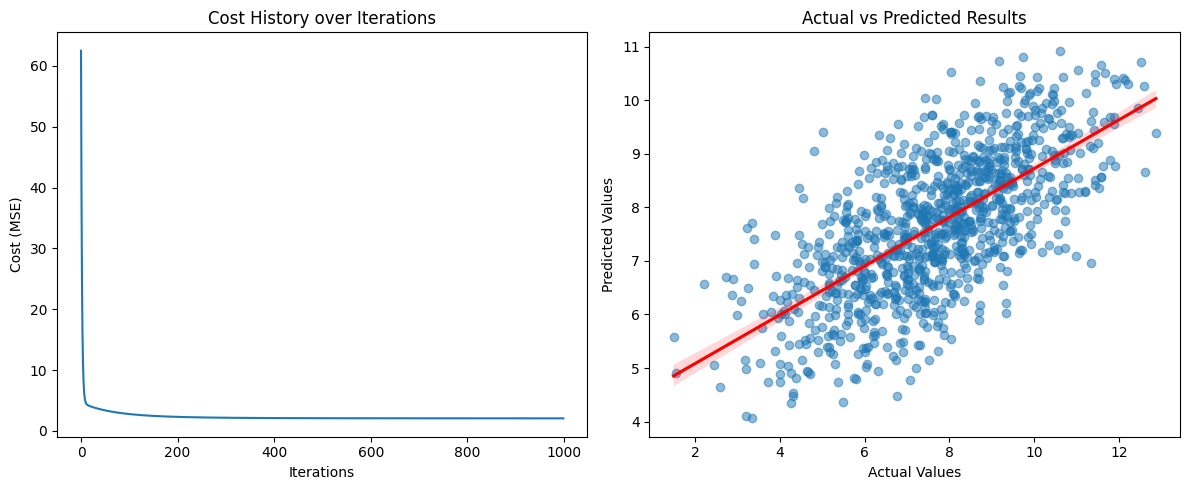

In [16]:
y_pred = model.predict(X)

plt.figure(figsize=(12, 5))

# Cost History Plot
plt.subplot(1, 2, 1)
plt.plot(model.cost_history)
plt.title("Cost History over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")

# Actual vs Predicted Plot
plt.subplot(1, 2, 2)
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Actual vs Predicted Results")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.tight_layout()
plt.show()